In [1]:
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from typing import TypedDict, Annotated, List 
from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
llm = ChatOllama(model= 'gemma3:1b')

In [3]:
class ChatState(TypedDict):
  messages :Annotated[list[BaseMessage], add_messages]

In [4]:
llm = ChatOllama(model= 'gemma3:1b' )
def chat_bot(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

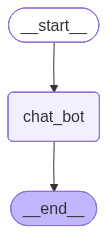

In [5]:
graph = StateGraph(ChatState)
graph.add_node('chat_bot', chat_bot)
graph.add_edge(START, 'chat_bot')
graph.add_edge('chat_bot', END)
graph.compile(checkpointer=InMemorySaver())

In [6]:
chatbot = graph.compile(checkpointer=InMemorySaver())

In [7]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot =chatbot.get_state(initial_state, config={'thread_id':'2'})

TypeError: Pregel.get_state() got multiple values for argument 'config'

In [ ]:
print(chatbot)